   LAYER 2  —  XGBoost (duration + campaign added)
   Input     : layer1_positives.csv
   YES floor : 80%
   NO  floor : 60%

Loaded 5983 rows from Layer 1 pool
  Real YES : 532 (8.9%)
  Real NO  : 5451 (91.1%)

Columns : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing', 'duration', 'campaign', 'y_enc', 'l1_prob', 'true_yes']

Layer 2 features (8) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing', 'duration']

Class imbalance in pool: YES=532 / NO=5451
scale_pos_weight = 10.25

Layer 2 train : 4786  test : 1197
[0]	validation_0-auc:0.84045
[100]	validation_0-auc:0.92180
[200]	validation_0-auc:0.92814
[238]	validation_0-auc:0.92804

Layer 2 trained ✓   best iter=188   AUC=0.9291

   LAYER 2  —  THRESHOLD SCAN
   ✅ = YES≥80% AND NO≥60%
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05     97.2%    55.4%     17.5%    29.6%     3    487
      0.06     97.

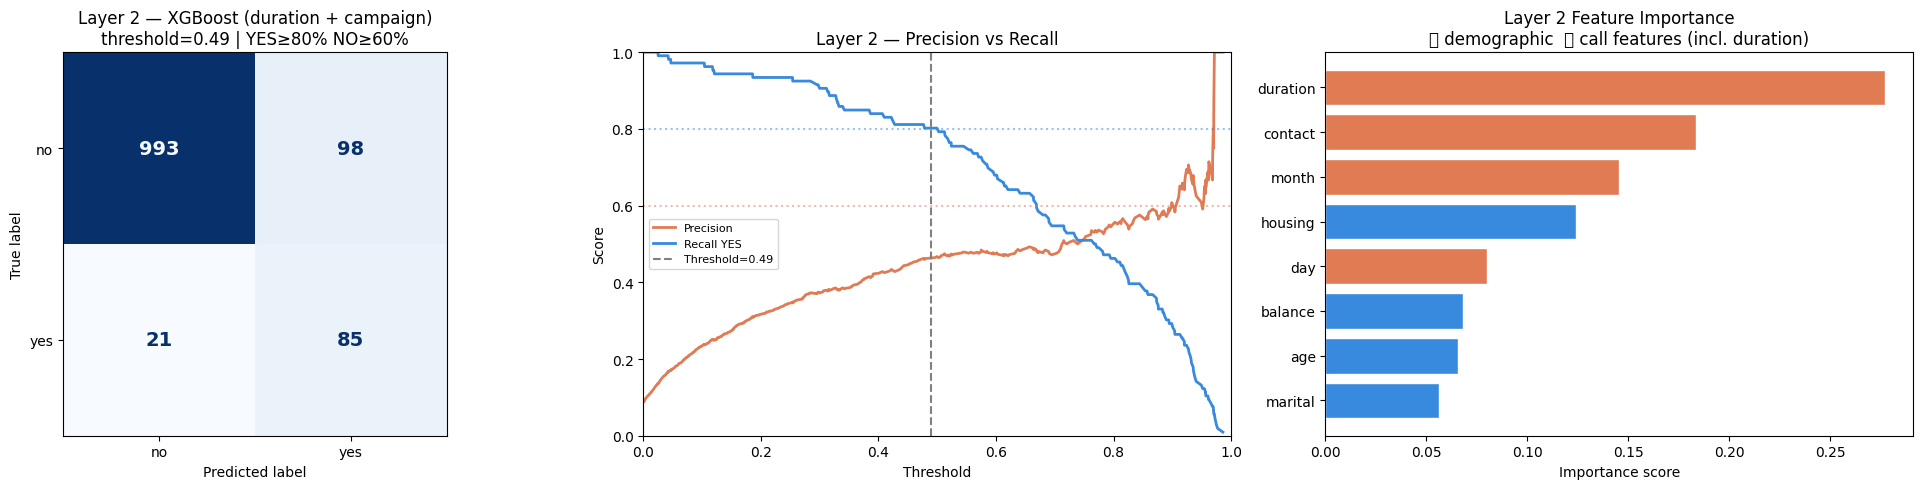


── INTERPRETATION ──
  duration  is expected to dominate Layer 2 importance.
  Short calls (<60s) → almost certainly NO.
  Long calls (>200s) → strong YES signal.
  Layer 2 uses this to cut the 5451 FP pool significantly.

  At threshold chosen above:
    YES recall : 80.2%  (kept ≥80% real YES)
    NO  recall : 91.0%  (rejected ≥60% FP from L1)
    YES prec   : 46.4%  (1 in 2.2 confirmed calls converts)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from xgboost import XGBClassifier

# ════════════════════════════════════════════════════════════════════
# LAYER 2  —  Refine the Layer 1 predicted-YES pool
#
# Input  : layer1_positives.csv  (only the 5983 people Layer 1 flagged)
# New    : duration + campaign  (only available after a call is made)
# Goal   : reduce the 5451 false positives → only call confirmed YES
#
# Key insight:
#   duration is the single strongest predictor of YES in the full data.
#   Layer 1 couldn't use it (pre-call). Now we can.
# ════════════════════════════════════════════════════════════════════

CSV_PATH = 'layer1_positives.csv'   # produced by layer1_extract.py

YES_RECALL_FLOOR = 0.80   # still want to keep ≥80% of real YES
NO_RECALL_FLOOR  = 0.60   # tighter than Layer 1 — we can afford it now
                           # (duration makes NO much more separable)

print("=" * 65)
print("   LAYER 2  —  XGBoost (duration + campaign added)")
print(f"   Input     : {CSV_PATH}")
print(f"   YES floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)

# ── load Layer 1 pool ─────────────────────────────────────────────────
pool_df = pd.read_csv(CSV_PATH)

print(f"\nLoaded {len(pool_df)} rows from Layer 1 pool")
print(f"  Real YES : {pool_df['true_yes'].sum()} "
      f"({pool_df['true_yes'].mean()*100:.1f}%)")
print(f"  Real NO  : {(pool_df['true_yes']==0).sum()} "
      f"({(pool_df['true_yes']==0).mean()*100:.1f}%)")
print(f"\nColumns : {list(pool_df.columns)}")

# ════════════════════════════════════════════════════════════════════
# FEATURE SET FOR LAYER 2
# Layer 1 features  +  duration  +  campaign
# ════════════════════════════════════════════════════════════════════

L2_FEATURES = [
    # ── inherited from Layer 1 ──────────────────────────────────────
    'day', 'month', 'contact', 'age', 'marital', 'balance', 'housing',
    # ── new: post-call information ──────────────────────────────────
    'duration',    # seconds the call lasted — strongest predictor
       
]

CAT_COLS = ['month', 'contact', 'marital', 'housing']

print(f"\nLayer 2 features ({len(L2_FEATURES)}) : {L2_FEATURES}")

# ── encode categoricals with LabelEncoder for XGBoost ─────────────────
from sklearn.preprocessing import LabelEncoder
le_dict = {}
pool_enc = pool_df.copy()

for col in CAT_COLS:
    le = LabelEncoder()
    pool_enc[col] = le.fit_transform(pool_enc[col].astype(str))
    le_dict[col] = le

X = pool_enc[L2_FEATURES].astype(np.float32)
y = pool_enc['true_yes'].astype(int)

print(f"\nClass imbalance in pool: YES={y.sum()} / NO={(y==0).sum()}")
scale_pos = (y == 0).sum() / y.sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

# ── train / test split (within the Layer 1 pool) ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nLayer 2 train : {len(X_train)}  test : {len(X_test)}")

# ── train XGBoost ─────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,    # handle imbalance
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100)

auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"\nLayer 2 trained ✓   best iter={xgb.best_iteration}   AUC={auc:.4f}")

# ════════════════════════════════════════════════════════════════════
# DUAL RECALL THRESHOLD SCAN
# ════════════════════════════════════════════════════════════════════

y_prob = xgb.predict_proba(X_test)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)

best_threshold = 0.5
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t, 'tn': tn_t, 'tp': tp_t,
            'valid': (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

print("\n" + "=" * 78)
print("   LAYER 2  —  THRESHOLD SCAN")
print(f"   ✅ = YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")
print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")

# ── final predictions ─────────────────────────────────────────────────
THRESHOLD    = best_threshold
y_pred_final = (y_prob >= THRESHOLD).astype(int)

cm             = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
yes_precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
yes_recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
no_recall      = tn / (tn + fp) if (tn + fp) > 0 else 0
yes_f1         = (2*yes_precision*yes_recall/(yes_precision+yes_recall)
                  if (yes_precision+yes_recall) > 0 else 0)
accuracy       = (tn + tp) / (tn + fp + fn + tp)

print(f"\nClassification Report (Layer 2, threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_final, target_names=['no','yes']))

# ════════════════════════════════════════════════════════════════════
# TWO-LAYER COMBINED STORY  (scaled to test set size)
# ════════════════════════════════════════════════════════════════════

# Layer 1 numbers (test set)
L1_TN = 1970; L1_FP = 5451; L1_FN = 47; L1_TP = 532

# Layer 2 numbers are on the pool test-split — scale to full pool for story
pool_ratio      = (L1_FP + L1_TP) / len(pool_df)
l2_tp_scaled    = int(round(tp / len(y_test) * (L1_FP + L1_TP)))
l2_fp_scaled    = int(round(fp / len(y_test) * (L1_FP + L1_TP)))
l2_fn_pool      = int(round(fn / len(y_test) * (L1_FP + L1_TP)))

print("\n" + "=" * 65)
print("   COMBINED TWO-LAYER STORY  (test set)")
print("=" * 65)
print(f"  Starting population         : {L1_TN+L1_FP+L1_FN+L1_TP} people")
print()
print(f"  ─── LAYER 1  (CatBoost, no duration) ───")
print(f"  Eliminated immediately      : {L1_TN} definite NO  → no call")
print(f"  Passed to calling queue     : {L1_FP+L1_TP} flagged as YES")
print(f"  Lost forever (FN)           : {L1_FN} real YES missed")
print()
print(f"  ─── LAYER 2  (XGBoost, duration added) ───")
print(f"  From the {L1_FP+L1_TP} who were called:")
print(f"    Confirmed YES             : ~{l2_tp_scaled} (offer made / followed up)")
print(f"    Rejected (noise removed)  : ~{l2_fp_scaled} (were FP in Layer 1)")
print(f"    Missed in Layer 2         : ~{l2_fn_pool} (further FN)")
print()
print(f"  NET: from {L1_TN+L1_FP+L1_FN+L1_TP} people → called {L1_FP+L1_TP} "
      f"→ confirmed ~{l2_tp_scaled}")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 2 — XGBoost (duration + campaign)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add', linestyle=':', alpha=0.5)
axes[1].axhline(y=NO_RECALL_FLOOR,  color='#e07b54', linestyle=':', alpha=0.5)
axes[1].set_title('Layer 2 — Precision vs Recall')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — feature importance
imp = xgb.feature_importances_
imp_df = pd.DataFrame({'feature': L2_FEATURES, 'importance': imp})
imp_df = imp_df.sort_values('importance', ascending=True)

DEMO_COLS = ['age', 'marital', 'balance', 'housing']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

colors = ['#e07b54' if f in CALL_COLS else '#378add'
          for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('Layer 2 Feature Importance\n'
                  '🔵 demographic  🟠 call features (incl. duration)')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# ── interpretation ────────────────────────────────────────────────────
print("\n── INTERPRETATION ──")
print("  duration  is expected to dominate Layer 2 importance.")
print("  Short calls (<60s) → almost certainly NO.")
print("  Long calls (>200s) → strong YES signal.")
print("  Layer 2 uses this to cut the 5451 FP pool significantly.")
print()
print("  At threshold chosen above:")
print(f"    YES recall : {yes_recall*100:.1f}%  (kept ≥{YES_RECALL_FLOOR*100:.0f}% real YES)")
print(f"    NO  recall : {no_recall*100:.1f}%  (rejected ≥{NO_RECALL_FLOOR*100:.0f}% FP from L1)")
print(f"    YES prec   : {yes_precision*100:.1f}%  (1 in {1/yes_precision if yes_precision>0 else 'inf':.1f} confirmed calls converts)")

   LAYER 2  —  Random Forest (duration added, no campaign)
   Input     : layer1_positives.csv
   YES floor : 80%
   NO  floor : 60%

Loaded 5983 rows from Layer 1 pool
  Real YES : 532 (8.9%)
  Real NO  : 5451 (91.1%)

Layer 2 features (8) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing', 'duration']

Train : 4786   Test : 1197
Class ratio in train — YES:426 / NO:4360

Running 5-fold CV AUC ...

  CV ROC-AUC per fold : ['0.9182', '0.9007', '0.9133', '0.9357', '0.9047']
  Mean  ± Std         : 0.9145 ± 0.0123

Final model  →  Test ROC-AUC : 0.9164
  (CV mean was 0.9145 — gap = 0.0019)

   LAYER 2  —  THRESHOLD SCAN
   ✅ = YES≥80% AND NO≥60%
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05     99.1%    41.7%     14.2%    24.8%     1    636
      0.06     98.1%    47.1%     15.3%    26.4%     2    577
      0.07     98.1%    52.2%     16.6%    28.5%     2    521
      

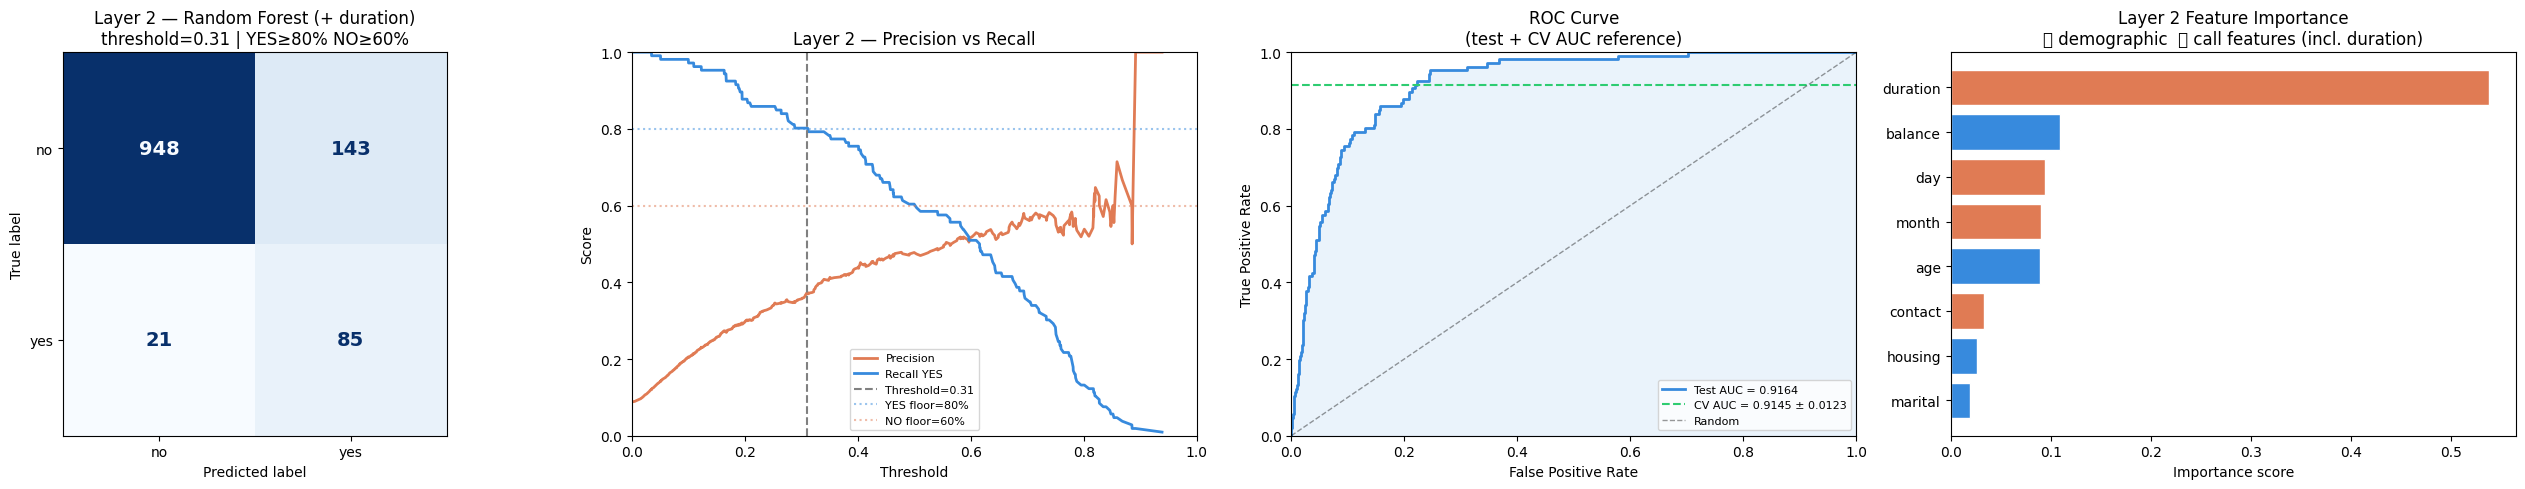

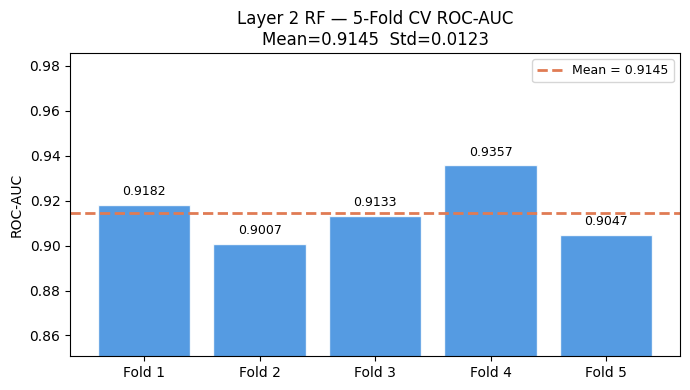


── SUMMARY ──
  CV ROC-AUC  : 0.9145 ± 0.0123  (5 folds on train)
  Test AUC    : 0.9164
  Threshold   : 0.31
  YES recall  : 80.2%   NO recall : 86.9%
  YES prec    : 37.3%

  'duration' is expected to be the #1 feature — short calls
  are almost always NO; long calls strongly predict YES.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)

# ════════════════════════════════════════════════════════════════════
# LAYER 2  —  Random Forest  (duration added, campaign excluded)
#
# Input  : layer1_positives.csv  (only the ~5983 people Layer 1 flagged)
# New    : duration  (post-call, strongest predictor)
# Goal   : from the Layer 1 pool, filter out false positives
# ════════════════════════════════════════════════════════════════════

CSV_PATH = 'layer1_positives.csv'

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.60   # tighter than Layer 1 — duration makes this achievable

print("=" * 65)
print("   LAYER 2  —  Random Forest (duration added, no campaign)")
print(f"   Input     : {CSV_PATH}")
print(f"   YES floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)

# ── load Layer 1 pool ─────────────────────────────────────────────────
pool_df = pd.read_csv(CSV_PATH)

print(f"\nLoaded {len(pool_df)} rows from Layer 1 pool")
print(f"  Real YES : {pool_df['true_yes'].sum()} "
      f"({pool_df['true_yes'].mean()*100:.1f}%)")
print(f"  Real NO  : {(pool_df['true_yes']==0).sum()} "
      f"({(pool_df['true_yes']==0).mean()*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════
# FEATURE SET  —  Layer 1 features + duration  (no campaign)
# ════════════════════════════════════════════════════════════════════

L2_FEATURES = [
    'day', 'month', 'contact', 'age', 'marital', 'balance', 'housing',
    'duration',   # ← the key addition: only available after a call
]

CAT_COLS = ['month', 'contact', 'marital', 'housing']

print(f"\nLayer 2 features ({len(L2_FEATURES)}) : {L2_FEATURES}")

# ── encode categoricals with LabelEncoder ─────────────────────────────
pool_enc = pool_df.copy()
le_dict  = {}
for col in CAT_COLS:
    le = LabelEncoder()
    pool_enc[col] = le.fit_transform(pool_enc[col].astype(str))
    le_dict[col] = le

X = pool_enc[L2_FEATURES].astype(np.float32)
y = pool_enc['true_yes'].astype(int)

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {len(X_train)}   Test : {len(X_test)}")
print(f"Class ratio in train — YES:{y_train.sum()} / NO:{(y_train==0).sum()}")

# ════════════════════════════════════════════════════════════════════
# CROSS-VALIDATED AUC  (5-fold, before final model)
# Gives a stable estimate before we touch the test set
# ════════════════════════════════════════════════════════════════════

rf_cv = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nRunning 5-fold CV AUC ...")
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf_cv, X_train, y_train,
                          cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"\n  CV ROC-AUC per fold : {[f'{v:.4f}' for v in cv_auc]}")
print(f"  Mean  ± Std         : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# ════════════════════════════════════════════════════════════════════
# FINAL MODEL  —  train on full train split, evaluate on test set
# ════════════════════════════════════════════════════════════════════

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print(f"\nFinal model  →  Test ROC-AUC : {test_auc:.4f}")
print(f"  (CV mean was {cv_auc.mean():.4f} — gap = {abs(test_auc - cv_auc.mean()):.4f})")

# ════════════════════════════════════════════════════════════════════
# DUAL RECALL THRESHOLD SCAN
# ════════════════════════════════════════════════════════════════════

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)

best_threshold = 0.5
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t, 'tn': tn_t, 'tp': tp_t,
            'valid': (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

print("\n" + "=" * 78)
print("   LAYER 2  —  THRESHOLD SCAN")
print(f"   ✅ = YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")
print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")

# ── final predictions ─────────────────────────────────────────────────
THRESHOLD    = best_threshold
y_pred_final = (y_prob >= THRESHOLD).astype(int)

cm             = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
yes_precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
yes_recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
no_recall_val  = tn / (tn + fp) if (tn + fp) > 0 else 0
yes_f1_val     = (2*yes_precision*yes_recall_val/(yes_precision+yes_recall_val)
                  if (yes_precision+yes_recall_val) > 0 else 0)
no_precision   = tn / (tn + fn) if (tn + fn) > 0 else 0
no_f1_val      = (2*no_precision*no_recall_val/(no_precision+no_recall_val)
                  if (no_precision+no_recall_val) > 0 else 0)

print(f"\nClassification Report (Layer 2, threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_final, target_names=['no','yes']))
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  YES recall : {yes_recall_val*100:.1f}%  (floor {YES_RECALL_FLOOR*100:.0f}%)")
print(f"  NO  recall : {no_recall_val*100:.1f}%  (floor {NO_RECALL_FLOOR*100:.0f}%)")
print(f"  YES prec   : {yes_precision*100:.1f}%")
print("=" * 60)

# ════════════════════════════════════════════════════════════════════
# TWO-LAYER COMBINED STORY
# ════════════════════════════════════════════════════════════════════

L1_TN = 1970; L1_FP = 5451; L1_FN = 47; L1_TP = 532
total  = L1_TN + L1_FP + L1_FN + L1_TP

# scale Layer 2 test numbers to full pool
pool_size  = L1_FP + L1_TP
test_size  = len(y_test)
scale      = pool_size / test_size

l2_tp_est  = int(round(tp  * scale))
l2_fp_est  = int(round(fp  * scale))
l2_fn_est  = int(round(fn  * scale))
l2_tn_est  = int(round(tn  * scale))

print("\n" + "=" * 65)
print("   COMBINED TWO-LAYER STORY  (test set, scaled estimates)")
print("=" * 65)
print(f"  Starting population              : {total}")
print()
print(f"  ─── LAYER 1  (CatBoost, pre-call) ───────────────────")
print(f"  Definite NO eliminated           : {L1_TN}  → no call needed")
print(f"  Flagged for calling              : {L1_FP + L1_TP}")
print(f"    ├── truly YES                  : {L1_TP}")
print(f"    └── false positives            : {L1_FP}")
print(f"  Real YES missed (FN)             : {L1_FN}  ← lost forever")
print()
print(f"  ─── LAYER 2  (RF + duration, post-call) ─────────────")
print(f"  From the {L1_FP + L1_TP} who were called:")
print(f"    Confirmed YES  (TP)            : ~{l2_tp_est}")
print(f"    FP removed     (TN in L2)      : ~{l2_tn_est}  ← noise filtered")
print(f"    Additional FN  (missed in L2)  : ~{l2_fn_est}")
print(f"    Remaining FP   (still noise)   : ~{l2_fp_est}")
print()
print(f"  NET: {total} people → {L1_FP+L1_TP} called → "
      f"~{l2_tp_est} confirmed YES")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# PLOTS  (4 panels)
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(26, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 2 — Random Forest (+ duration)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add', linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR,  color='#e07b54', linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Layer 2 — Precision vs Recall')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — ROC curve (test) + CV fold AUCs
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr_arr, tpr_arr, color='#378add', linewidth=2,
             label=f'Test AUC = {test_auc:.4f}')
axes[2].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='#378add')
# shade CV range
axes[2].axhline(y=cv_auc.mean(), color='#2ecc71', linestyle='--',
                linewidth=1.5,
                label=f'CV AUC = {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
axes[2].set_title('ROC Curve\n(test + CV AUC reference)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])

# 4 — feature importance
imp_df = pd.DataFrame({
    'feature'   : L2_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

DEMO_COLS = ['age', 'marital', 'balance', 'housing']
CALL_COLS = ['contact', 'day', 'month', 'duration']

colors = ['#e07b54' if f in CALL_COLS else '#378add'
          for f in imp_df['feature']]

axes[3].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[3].set_title('Layer 2 Feature Importance\n'
                  '🔵 demographic  🟠 call features (incl. duration)')
axes[3].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# ── CV fold bar chart ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
fold_labels = [f'Fold {i+1}' for i in range(len(cv_auc))]
bars = ax2.bar(fold_labels, cv_auc, color='#378add', edgecolor='white', alpha=0.85)
ax2.axhline(y=cv_auc.mean(), color='#e07b54', linestyle='--', linewidth=2,
            label=f'Mean = {cv_auc.mean():.4f}')
ax2.set_ylim([max(0, cv_auc.min() - 0.05), min(1, cv_auc.max() + 0.05)])
ax2.set_title(f'Layer 2 RF — 5-Fold CV ROC-AUC\nMean={cv_auc.mean():.4f}  Std={cv_auc.std():.4f}')
ax2.set_ylabel('ROC-AUC')
ax2.legend(fontsize=9)
for bar, val in zip(bars, cv_auc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\n── SUMMARY ──")
print(f"  CV ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}  (5 folds on train)")
print(f"  Test AUC    : {test_auc:.4f}")
print(f"  Threshold   : {THRESHOLD:.2f}")
print(f"  YES recall  : {yes_recall_val*100:.1f}%   NO recall : {no_recall_val*100:.1f}%")
print(f"  YES prec    : {yes_precision*100:.1f}%")
print()
print("  'duration' is expected to be the #1 feature — short calls")
print("  are almost always NO; long calls strongly predict YES.")